### Supp. Split trials into those with next or without next representations

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt
from spyglass.shijiegu.changeOfMind import nodes, color_by_rat


[2026-03-26 16:33:46,660][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[16:33:59][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[16:33:59][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[16:33:59][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[16:33:59][WARNING] Spyglass: Deprecation: this class has b

In [2]:
def return_save_name(animal, parameter_name, d1, d2, minimum_duration, min_posterior, proportion = 0.1, use_1d = 1):
    save_name = f'{animal.lower()}_{parameter_name}_{d1}_{d2}_t{minimum_duration}_minp{min_posterior}_p{proportion}_use1d{use_1d}_remoteGLM'
    return save_name

In [3]:
list_of_days_animals = {}
seq_animals = {}
success_animal = {}

# encoding_set = 'all_maze'
# classifier_param_name = 'default_decoding_gpu_4armMaze'

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']
seq_animals[animal] = 'rev2'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = 'seq2'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
seq_animals[animal] = 'seq2'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']#'20231111']
seq_animals[animal] = 'rev2'

In [4]:
parameter_name = "params_both_max_run_time_2_state" 
minimum_duration = 0.02
min_posterior = 0.2
#parameter_name = "params_both_max_all_maze_2_state" 

In [62]:
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm

def sd_err(arr):
    N = len(arr)
    p = np.sum(arr)/ N
    return np.sqrt((p * (1-p) / N))

def plot_one_axis(data1, data2, animal_ind, ax, animal, draw_annotation = False, draw_text = True):
    std = [sd_err(data1), sd_err(data2)]
    mean = [np.mean(data1), np.mean(data2)]
    ax.bar([0 + animal_ind,
                0.3 + animal_ind],mean, yerr=std, width=0.25, hatch=['', '////'],color = color_by_rat[animal], alpha=0.8)
    if draw_text:
        if len(data1) == 0:
            ax.text(animal_ind - 0.15, 0 + 0.05, 0, fontsize = 6)
        else:
            ax.text(animal_ind - 0.15, mean[0]+std[0] + 0.05, len(data1), fontsize = 6)
        ax.text(animal_ind + 0.3 - 0.15, mean[1]+std[1] + 0.05, len(data2), fontsize = 6)
        
    table = np.array([[np.sum(data1 == 0), np.sum(data1 == 1)],[np.sum(data2 == 0), np.sum(data2 == 1)]])
    res = fisher_exact(table, alternative = "greater")
    p_value = res.pvalue
    print("p_value", p_value)
    if p_value < 0.05 and draw_annotation:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.3, np.round(p_value, 4))], ax = ax)
    return ax, p_value

def plot_one_axis3(data1, data2, data3, animal_ind, ax, animal, draw_annotation = False, draw_text = True):
    std = [sd_err(data1), sd_err(data2), sd_err(data3)]
    mean = [np.mean(data1), np.mean(data2), np.mean(data3)]
    ax.bar([0 + animal_ind,
                0.2 + animal_ind,
                   0.4 + animal_ind],
           mean, yerr=std, width=0.18, hatch=['', '\\\\', "////"],
           color = color_by_rat[animal], alpha=0.7)
    if draw_text:
        ax.text(animal_ind - 0.1, mean[0]+std[0], len(data1), fontsize = 6)
        ax.text(animal_ind + 0.2 - 0.1, mean[1]+std[1] + 0.05, len(data2), fontsize = 6)
        ax.text(animal_ind + 0.4 - 0.1, mean[2]+std[2] + 0.05, len(data3), fontsize = 6)
        
    return ax

molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.25563909774436094
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.5003295978905735
julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.7582035595105673
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.6763518052302341
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.2134569258288352


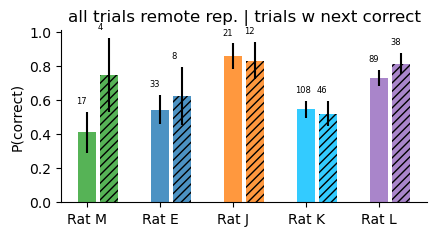

In [82]:
# Plotting
fig, ax = plt.subplots(figsize=(5, 3))
feature_names = ["constant", "previous", "previously_rewarded", "future", "future_correct","same side","switch side"]

animal_ind = 0
animals = ["molly", "eliot","julio","klein","lewis"]#["lewis","molly","julio","klein"]
num_of_com = {} #number of change of mind considered
for animal in animals:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                 minimum_duration = minimum_duration, min_posterior = min_posterior, proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    features_all, response_all = data["features_all"], data["response_all"]
    tally_dict = data["tally_dict"]

    Z = np.array([d[-1] == 1 for d in tally_dict]) #reward or not
    Y_next = []
    Y_correct = []
    Y_neither = []
    for trial in range(len(features_all)):
        x = features_all[trial] > 0
        y = np.array(response_all[trial])

        correct_next = np.sum(y[x[:,3]].astype("int")) > 0
        Y_correct.append( correct_next ) # correct next


        _next = np.sum(y[x[:,2]].astype("int")) > 0
        Y_next.append( _next ) # next

        #neither = np.logical_and(~x[:,3],~x[:,2])
        #neither = np.sum(y[neither].astype("int")) > 0
        Y_neither.append( True ) # neither

    Y_correct = np.array(Y_correct)
    Y_next = np.array(Y_next)
    Y_neither = np.array(Y_neither)
    
    data1 = Z[Y_neither]
    data2 = Z[Y_next]
    data3 = Z[Y_correct]

    plot_one_axis(data1, data3, animal_ind, ax, animal, draw_annotation = True, draw_text = True)
    
    animal_ind += 1

ax.set_title('all trials remote rep. | trials w next correct')

ax.set_xticks(np.arange(len(animals)));
ax.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
ax.set_ylabel("P(correct)")
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
#plt.show()

fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/correct_incorrect_next_correct_rep.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

### GLM

In [123]:
GLM_xy = []
animals = ["molly", "eliot","julio","klein","lewis"]#["lewis","molly","julio","klein"]
num_of_com = {} #number of change of mind considered
for animal in animals:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                 minimum_duration = minimum_duration, min_posterior = min_posterior, proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    features_all, response_all = data["features_all"], data["response_all"]
    tally_dict = data["tally_dict"]

    Z = np.array([d[-1] == 1 for d in tally_dict]) #reward or not
    Y_next = []
    Y_correct = []
    Y_overall = []
    for trial in range(len(features_all)):
        x = features_all[trial] > 0
        y = np.array(response_all[trial])

        correct_next = np.sum(y[x[:,3]].astype("int")) > 0
        Y_correct.append( correct_next ) # correct next


        _next = np.sum(y[x[:,2]].astype("int")) > 0
        Y_next.append( _next ) # next

        neither = np.logical_and(~x[:,3],~x[:,2])
        neither = np.sum(y[neither].astype("int")) > 0
        Y_overall.append( neither ) # neither

    Y_correct = np.array(Y_correct)
    Y_next = np.array(Y_next)
    Y_overall = np.array(Y_overall)
    animal_category = [a == animal for a in animals]
    for ind in range(len(Z)):
        GLM_xy.append(animal_category + [Y_correct[ind], Y_next[ind], Y_overall[ind], Z[ind]])
    
GLM_xy = np.array(GLM_xy).astype("int")

molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0.2_p0.1_use1d1_remoteGLM
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0.2_p0.1_use1d1_remoteGLM
julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0.2_p0.1_use1d1_remoteGLM
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0.2_p0.1_use1d1_remoteGLM
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0.2_p0.1_use1d1_remoteGLM


In [129]:
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_xy[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["correct next"] = GLM_xy[:,(len(animals))]
feature_dict["next"] = GLM_xy[:,len(animals) + 1]
feature_dict["other"] = GLM_xy[:,len(animals) + 2]

In [130]:
X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_xy[:,-1].astype("int").reshape((-1,1))

"""b) Logistic"""
logistic_model = sm.Logit(y, X)
logistic_result2 = logistic_model.fit()

# 3. View the model summary
print("===== start ===== ")
print("\n \n Mixed Logistics \n",logistic_result2.summary())
print("===== end ===== ")

Optimization terminated successfully.
         Current function value: 0.595693
         Iterations 7
===== start ===== 

 
 Mixed Logistics 
                            Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  268
Model:                          Logit   Df Residuals:                      260
Method:                           MLE   Df Model:                            7
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.1009
Time:                        18:17:09   Log-Likelihood:                -159.65
converged:                       True   LL-Null:                       -177.55
Covariance Type:            nonrobust   LLR p-value:                 7.862e-06
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.5300        nan        nan        nan       

molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.06666666666666667
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.0012626262626262625
1.705 0.03
julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 1.0
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 3.215395507181211e-08
3.9050000000000002 0.03
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 5.885252852057604e-06
5.005 0.03


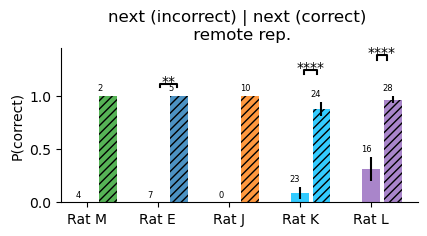

In [86]:
# Plotting
fig, ax = plt.subplots(figsize=(5, 3))
feature_names = ["constant", "previous", "previously_rewarded", "future", "future_correct","same side","switch side"]

animal_ind = 0
animals = ["molly", "eliot","julio","klein","lewis"]#["lewis","molly","julio","klein"]
num_of_com = {} #number of change of mind considered
for animal in animals:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                 minimum_duration = minimum_duration, min_posterior = min_posterior, proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    features_all, response_all = data["features_all"], data["response_all"]
    tally_dict = data["tally_dict"]

    Z = np.array([d[-1] == 1 for d in tally_dict]) #reward or not
    Y_next = [] #incorrect
    Y_correct = []
    for trial in range(len(features_all)):
        x = features_all[trial] > 0
        y = np.array(response_all[trial])

        correct = x[:,3]
        _next = x[:,2]
        correct_next = np.logical_and(correct, _next)
        correct_next = np.sum(y[correct_next].astype("int")) > 0
        Y_correct.append( correct_next ) # correct next

        incorrect = ~x[:,3]
        _next = x[:,2]
        incorrect_next = np.logical_and(incorrect, _next)
        _next = np.sum(y[incorrect_next].astype("int")) > 0
        Y_next.append( _next ) # next

    Y_correct = np.array(Y_correct)
    Y_next = np.array(Y_next)
    
    data1 = Z[Y_next]
    data2 = Z[Y_correct]

    plot_one_axis(data1, data2, animal_ind, ax, animal, draw_annotation = True, draw_text = True)
    
    animal_ind += 1

ax.set_title('next (incorrect) | next (correct) \n remote rep.')

ax.set_xticks(np.arange(len(animals)));
ax.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
ax.set_ylabel("P(correct)")
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
#plt.show()

fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/correct_rate_next_correct_vs_next_incorrect_rep.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.16176470588235295
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.47844178489339767
julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.7837606837606838
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.6251556661819129
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.12131951188884446


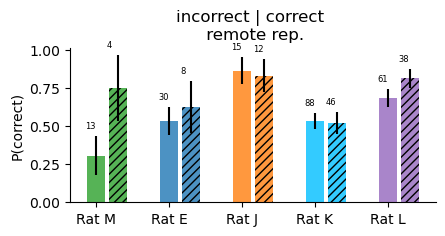

In [87]:
# Plotting
fig, ax = plt.subplots(figsize=(5, 3))
feature_names = ["constant", "previous", "previously_rewarded", "future", "future_correct","same side","switch side"]

animal_ind = 0
animals = ["molly", "eliot","julio","klein","lewis"]#["lewis","molly","julio","klein"]
num_of_com = {} #number of change of mind considered
for animal in animals:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                 minimum_duration = minimum_duration, min_posterior = min_posterior, proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    features_all, response_all = data["features_all"], data["response_all"]
    tally_dict = data["tally_dict"]

    Z = np.array([d[-1] == 1 for d in tally_dict]) #reward or not
    Y_next = [] #incorrect
    Y_correct = []
    for trial in range(len(features_all)):
        x = features_all[trial] > 0
        y = np.array(response_all[trial])
        
        correct = x[:,3]
        _correct = np.sum(y[correct].astype("int")) > 0
        Y_correct.append( _correct ) # next

        incorrect = ~x[:,3]
        _next = np.sum(y[incorrect].astype("int")) > 0
        Y_next.append( _next ) # next

    Y_correct = np.array(Y_correct)
    Y_next = np.array(Y_next)
    
    data1 = Z[Y_next]
    data2 = Z[Y_correct]

    plot_one_axis(data1, data2, animal_ind, ax, animal, draw_annotation = True, draw_text = True)
    
    animal_ind += 1

ax.set_title('incorrect | correct \n remote rep.')

ax.set_xticks(np.arange(len(animals)));
ax.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
ax.set_ylabel("P(correct)")
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
#plt.show()

fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/correct_rate_correct_vs_incorrect_rep.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")